In [1]:
from google.colab import files

uploaded = files.upload()

Saving stroke_prediction_dataset.csv to stroke_prediction_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [3]:
import pandas as pd

df = pd.read_csv("stroke_prediction_dataset.csv")

df.head()

,Patient ID,Patient Name,Age,Gender,Hypertension,Heart Disease,Marital Status,Work Type,Residence Type,Average Glucose Level,...,Alcohol Intake,Physical Activity,Stroke History,Family History of Stroke,Dietary Habits,Stress Levels,Blood Pressure Levels,Cholesterol Levels,Symptoms,Diagnosis
0,18153,Mamooty Khurana,56,Male,0,1,Married,Self-employed,Rural,130.91,...,Social Drinker,Moderate,0,Yes,Vegan,3.48,140/108,"HDL: 68, LDL: 133","Difficulty Speaking, Headache",Stroke
1,62749,Kaira Subramaniam,80,Male,0,0,Single,Self-employed,Urban,183.73,...,Never,Low,0,No,Paleo,1.73,146/91,"HDL: 63, LDL: 70","Loss of Balance, Headache, Dizziness, Confusion",Stroke
2,32145,Dhanush Balan,26,Male,1,1,Married,Never Worked,Rural,189.00,...,Rarely,High,0,Yes,Paleo,7.31,154/97,"HDL: 59, LDL: 95","Seizures, Dizziness",Stroke
3,6154,Ivana Baral,73,Male,0,0,Married,Never Worked,Urban,185.29,...,Frequent Drinker,Moderate,0,No,Paleo,5.35,174/81,"HDL: 70, LDL: 137","Seizures, Blurred Vision, Severe Fatigue, Head...",No Stroke
4,48973,Darshit Jayaraman,51,Male,1,1,Divorced,Self-employed,Urban,177.34,...,Rarely,Low,0,Yes,Pescatarian,6.84,121/95,"HDL: 65, LDL: 68",Difficulty Speaking,Stroke


In [4]:
df.shape

(15000, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient ID                15000 non-null  int64  
 1   Patient Name              15000 non-null  object 
 2   Age                       15000 non-null  int64  
 3   Gender                    15000 non-null  object 
 4   Hypertension              15000 non-null  int64  
 5   Heart Disease             15000 non-null  int64  
 6   Marital Status            15000 non-null  object 
 7   Work Type                 15000 non-null  object 
 8   Residence Type            15000 non-null  object 
 9   Average Glucose Level     15000 non-null  float64
 10  Body Mass Index (BMI)     15000 non-null  float64
 11  Smoking Status            15000 non-null  object 
 12  Alcohol Intake            15000 non-null  object 
 13  Physical Activity         15000 non-null  object 
 14  Stroke

## Member 5 - Feature Selection

### Introduction

Feature selection is the process of identifying and removing irrelevant attributes from a dataset.

Removing unnecessary features reduces noise, improves efficiency, and helps focus on the most important predictors.

In [6]:
df.columns

Index(['Patient ID', 'Patient Name', 'Age', 'Gender', 'Hypertension',
       'Heart Disease', 'Marital Status', 'Work Type', 'Residence Type',
       'Average Glucose Level', 'Body Mass Index (BMI)', 'Smoking Status',
       'Alcohol Intake', 'Physical Activity', 'Stroke History',
       'Family History of Stroke', 'Dietary Habits', 'Stress Levels',
       'Blood Pressure Levels', 'Cholesterol Levels', 'Symptoms', 'Diagnosis'],
      dtype='object')

In [7]:
print("Number of Columns Before:", len(df.columns))

Number of Columns Before: 22


In [8]:
df.drop('Patient ID', axis=1, inplace=True)

df.drop('Patient Name', axis=1, inplace=True)

In [9]:
df.columns

Index(['Age', 'Gender', 'Hypertension', 'Heart Disease', 'Marital Status',
       'Work Type', 'Residence Type', 'Average Glucose Level',
       'Body Mass Index (BMI)', 'Smoking Status', 'Alcohol Intake',
       'Physical Activity', 'Stroke History', 'Family History of Stroke',
       'Dietary Habits', 'Stress Levels', 'Blood Pressure Levels',
       'Cholesterol Levels', 'Symptoms', 'Diagnosis'],
      dtype='object')

In [10]:
print("Number of Columns After:", len(df.columns))

Number of Columns After: 20


### Feature Selection

The Patient ID and Patient Name attributes were removed.

Patient ID is a unique identifier and does not contribute to prediction.

Patient Name is a personal identifier and does not provide meaningful information for stroke prediction.

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
X = df.drop('Diagnosis', axis=1)

y = df['Diagnosis']

In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

importance.head(10)

,0
Blood Pressure Levels,0.108598
Stress Levels,0.106958
Cholesterol Levels,0.106913
Body Mass Index (BMI),0.106751
Average Glucose Level,0.105596
Age,0.092328
Symptoms,0.090013
Dietary Habits,0.047716
Alcohol Intake,0.033267
Work Type,0.033185


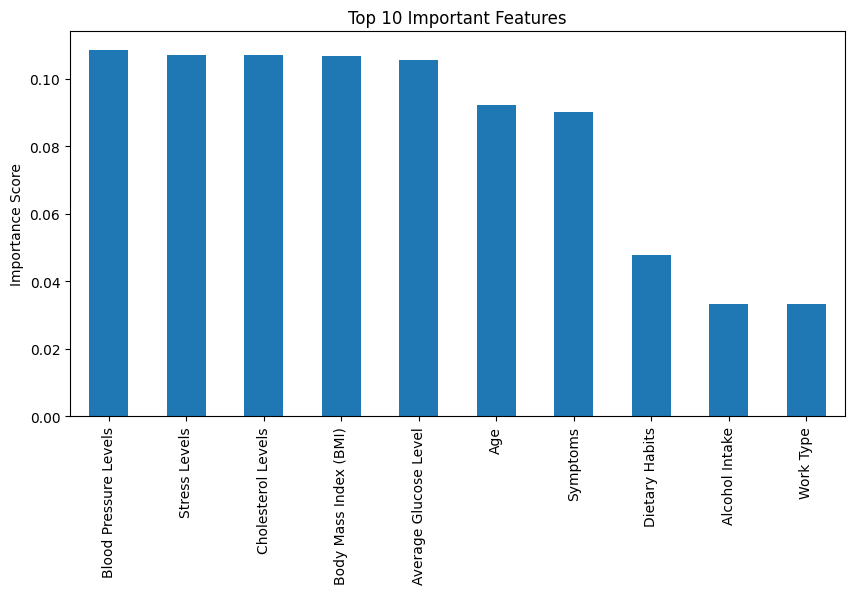

In [ ]:
importance.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Important Features")

plt.ylabel("Importance Score")

plt.show()

In [ ]:
df.drop('Blood Pressure Levels', axis=1, inplace=True)

### Feature Importance Analysis

A Random Forest Classifier was used to evaluate feature importance.

The results indicate that several health-related attributes, such as Blood Pressure Levels, Stress Levels, Cholesterol Levels, Body Mass Index (BMI), and Average Glucose Level, contribute significantly to stroke prediction.

Features with higher importance scores have a greater influence on the model's decision-making process.

### Feature Selection Results

Feature selection was performed to remove attributes that do not contribute meaningful information for stroke prediction.

- Patient ID was removed because it is a unique identifier.
- Patient Name was removed because it contains personal information and does not help prediction.
- The original Blood Pressure Levels attribute was removed because it was transformed into two new features:
  - Systolic_BP
  - Diastolic_BP

Removing unnecessary attributes helps reduce redundancy and improve the quality of the final dataset.